In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np



In [14]:
device = torch.device('mps')

DATA_ROOT = './data'

FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_ROOT, train=True,  download=True, transform=transform
)
test_dataset  = torchvision.datasets.FashionMNIST(
    root=DATA_ROOT, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=0, pin_memory=False)

print(f'train: {len(train_dataset):,}')
print(f'test: {len(test_dataset):,}')

train: 60,000
test: 10,000


In [16]:
class AEEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Flatten(),
            nn.Linear(128*4*4, latent_dim)
        )

    def forward(self, x):
        h = self.conv(x)
        return h


class AEDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()

        self.bottleneck_up = nn.Linear(latent_dim, 128*4*4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=3, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.bottleneck_up(z).view(-1, 128, 4, 4)
        return self.deconv(x)


class AE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = AEEncoder(latent_dim)
        self.decoder = AEDecoder(latent_dim)

    def forward(self, x):
        d = self.encoder(x)
        dec = self.decoder(d)
        return dec

model = AE(128).to(device)

In [17]:
optimizer = optim.Adam(model.parameters())
loss_fn = nn.L1Loss()
history = {'train_loss': [], 'bce': [], 'kl': []}

In [18]:
import tqdm

for epoch in range(30):
    model.train()
    
    tot_loss = tot_bce = tot_kl = 0.0

    for imgs, _ in tqdm.tqdm(train_loader):
        imgs = imgs.to(device)
        
        output = model(imgs)
        loss = loss_fn(output, imgs)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


  7%|▋         | 35/469 [00:00<00:07, 59.34it/s]


KeyboardInterrupt: 

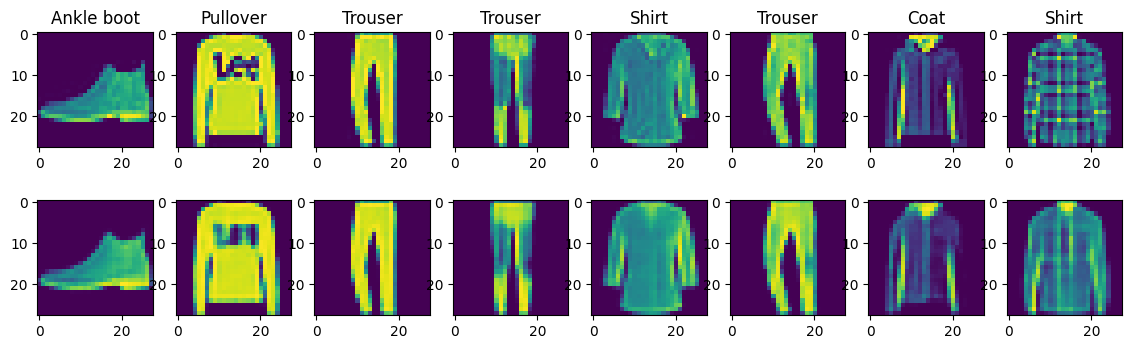

In [ ]:
model.eval()
test_imgs, test_labels = next(iter(test_loader))
test_imgs_dev = test_imgs[:8].to(device)

with torch.no_grad():
    recon_imgs = model(test_imgs_dev)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(test_imgs[i, 0].numpy())
    axes[0, i].set_title(FASHION_LABELS[test_labels[i]])
    axes[1, i].imshow(recon_imgs[i, 0].cpu().numpy())

plt.show()

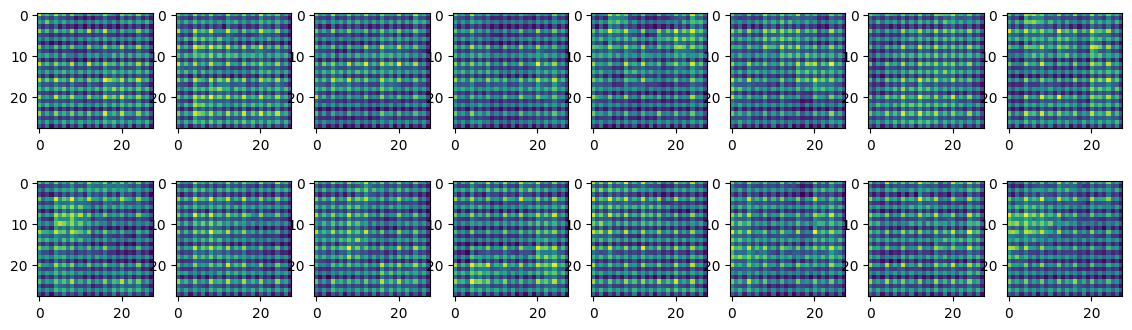

In [34]:
model.eval()
n_samples = 16

with torch.no_grad():
    z = torch.randn(n_samples, 128, device=device)
    samples = model.decoder(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i, 0].numpy())

plt.show()